# Occlusion Estimator Audit on DMD Dataset

**Purpose:** Evaluate how well the ROF-trained occlusion estimator (ResNet-34, 2-logit head) performs on actual DMD frames.

This is the **critical first step** before any synthetic occlusion experiments or journal extensions. If the estimator's predictions don't correlate with DMD's annotation-derived occlusion labels, the entire gating pipeline may not be functioning on DMD data.

**Key questions:**
1. For Subject 1 (glasses): does `p_eye` come out higher than for non-glasses subjects?
2. For `yawn_with_hand` frames: does `p_mouth` come out higher than `yawn_without_hand` or `Neutral`?
3. What is the ROC-AUC of `p_eye` vs `eyes_occluded_prior`? Same for `p_mouth` vs `mouth_occluded_prior`?
4. What do the prediction distributions look like across all 15 subjects?

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.metrics import confusion_matrix, classification_report

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150

print('Imports ready.')

Imports ready.


In [2]:
from occlusion_audit_utils import (
    CONFIG,
    load_csv_video_data,
    FaceDetector,
    ResNet34OcclusionModel,
    sample_frames_for_audit,
    extract_and_predict,
)

print('Utilities loaded.')
print(f"Occlusion model checkpoint: {CONFIG['RESNET34_OCCLUSION_MODEL_PATH']}")
print(f"Dataset path: {CONFIG['CSV_DATASET_PATH']}")

Utilities loaded.
Occlusion model checkpoint: resnet34_occlusion.pt
Dataset path: Data


## 1. Load CSV Annotations (All 15 Subjects)

In [3]:
csv_data = load_csv_video_data(CONFIG['CSV_DATASET_PATH'], filter_eye_states=True)
print(f"\nLoaded {len(csv_data)} videos from {len(set(m['subject'] for m in csv_data.values()))} subjects.")
print(f"Total annotated frames: {sum(m['total_frames'] for m in csv_data.values()):,}")

Loading CSV video data from: Data
  Sub1_sub1_video: 4256 frames (filtered 1224)
  Sub10_sub10_video: 4440 frames (filtered 1615)
  Sub11_sub11_video: 4049 frames (filtered 1328)
  Sub12_sub12_video: 4562 frames (filtered 1014)
  Sub13_sub13_video: 4246 frames (filtered 1134)
  Sub14_sub14_video: 4585 frames (filtered 929)
  Sub15_sub15_video: 3957 frames (filtered 1337)
  Sub2_sub2_video: 4218 frames (filtered 1198)
  Sub3_sub3_video: 3463 frames (filtered 2064)
  Sub4_sub4_video: 3829 frames (filtered 1400)
  Sub5_sub5_video: 3642 frames (filtered 1645)
  Sub6_sub6_video: 4031 frames (filtered 1379)
  Sub7_sub7_video: 3708 frames (filtered 1697)
  Sub8_sub8_video: 4345 frames (filtered 1062)
  Sub9_sub9_video: 3977 frames (filtered 1315)

Loaded 15 videos from 15 subjects.
Total annotated frames: 61,308


In [4]:
# Quick look at the annotation distributions BEFORE running the model
all_anns = []
for vk, meta in csv_data.items():
    for ann in meta['annotations']:
        all_anns.append({
            'subject': meta['subject'],
            'class_label': ann.class_label,
            'variant': ann.variant,
            'eyes_state': ann.eyes_state,
            'yawn_with_hand': ann.yawn_with_hand,
            'glasses': ann.glasses,
            'eyes_occluded_prior': ann.eyes_occluded_prior,
            'mouth_occluded_prior': ann.mouth_occluded_prior,
        })
ann_df = pd.DataFrame(all_anns)

print("=" * 60)
print("ANNOTATION SUMMARY (before running estimator)")
print("=" * 60)
print(f"\nTotal frames: {len(ann_df):,}")
print(f"\nClass distribution:")
print(ann_df['class_label'].value_counts().to_string())
print(f"\nEyes occluded (prior): {ann_df['eyes_occluded_prior'].sum():,} / {len(ann_df):,}  ({ann_df['eyes_occluded_prior'].mean()*100:.1f}%)")
print(f"Mouth occluded (prior): {ann_df['mouth_occluded_prior'].sum():,} / {len(ann_df):,}  ({ann_df['mouth_occluded_prior'].mean()*100:.1f}%)")
print(f"Glasses: {ann_df['glasses'].sum():,} / {len(ann_df):,}  ({ann_df['glasses'].mean()*100:.1f}%)")
print(f"Yawn with hand: {ann_df['yawn_with_hand'].sum():,} / {len(ann_df):,}  ({ann_df['yawn_with_hand'].mean()*100:.1f}%)")

print(f"\nPer-subject occlusion:")
occ_by_sub = ann_df.groupby('subject').agg(
    n_frames=('class_label', 'count'),
    eyes_occ=('eyes_occluded_prior', 'sum'),
    mouth_occ=('mouth_occluded_prior', 'sum'),
    has_glasses=('glasses', 'any'),
    has_yawn_hand=('yawn_with_hand', 'any'),
).sort_index(key=lambda x: x.str.extract(r'(\d+)')[0].astype(int))
print(occ_by_sub.to_string())

ANNOTATION SUMMARY (before running estimator)

Total frames: 61,308

Class distribution:
class_label
Neutral      46486
EyeClosed     7475
Yawn          7347

Eyes occluded (prior): 8,213 / 61,308  (13.4%)
Mouth occluded (prior): 3,671 / 61,308  (6.0%)
Glasses: 8,213 / 61,308  (13.4%)
Yawn with hand: 3,671 / 61,308  (6.0%)

Per-subject occlusion:
         n_frames  eyes_occ  mouth_occ  has_glasses  has_yawn_hand
subject                                                           
Sub1         4256      4256        300         True           True
Sub2         4218         0        234        False           True
Sub3         3463         0        198        False           True
Sub4         3829         0        227        False           True
Sub5         3642         0        181        False           True
Sub6         4031         0        226        False           True
Sub7         3708         0        238        False           True
Sub8         4345         0        322        Fa

## 2. Initialize Models

In [5]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

face_detector = FaceDetector(
    shape_model_path=CONFIG['DLIB_MODEL_PATH'],
    det_size=(768, 768),
    det_thresh=0.35,
)

occ_model = ResNet34OcclusionModel(
    ckpt_path=CONFIG['RESNET34_OCCLUSION_MODEL_PATH'],
    device=device,
)

print(f'\nBoth models initialized on {device}.')

Using device: cpu
Initializing RetinaFace detector...
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/mehaksaleem/.insightface/models/buffalo_sc/det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/mehaksaleem/.insightface/models/buffalo_sc/w600k_mbf.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (768, 768)
  RetinaFace (buffalo_sc) + dlib 68pt ready  [thresh=0.35]

Both models initialized on cpu.


## 3. Extract Frames and Run Predictions

Running on **all** annotated frames across all 15 subjects (no sampling).

In [6]:
# Set to None for ALL frames, or a number (e.g. 50, 100, 300) for quick CPU testing
MAX_PER_SUBJECT = 50

print(f"Sampling frames (max {MAX_PER_SUBJECT} per subject) ...")
sampled = sample_frames_for_audit(csv_data, max_per_subject=MAX_PER_SUBJECT, include_all_occluded=True, seed=42)

total_sampled = sum(len(v) for v in sampled.values())
print(f"\nTotal: {total_sampled} frames across {len(sampled)} videos")

Sampling frames (max 50 per subject) ...
  Sub1_sub1_video: 50 occluded + 0 non-occluded = 50 frames
  Sub10_sub10_video: 4 occluded + 46 non-occluded = 50 frames
  Sub11_sub11_video: 3 occluded + 47 non-occluded = 50 frames
  Sub12_sub12_video: 2 occluded + 48 non-occluded = 50 frames
  Sub13_sub13_video: 3 occluded + 47 non-occluded = 50 frames
  Sub14_sub14_video: 1 occluded + 49 non-occluded = 50 frames
  Sub15_sub15_video: 50 occluded + 0 non-occluded = 50 frames
  Sub2_sub2_video: 2 occluded + 48 non-occluded = 50 frames
  Sub3_sub3_video: 2 occluded + 48 non-occluded = 50 frames
  Sub4_sub4_video: 2 occluded + 48 non-occluded = 50 frames
  Sub5_sub5_video: 2 occluded + 48 non-occluded = 50 frames
  Sub6_sub6_video: 2 occluded + 48 non-occluded = 50 frames
  Sub7_sub7_video: 3 occluded + 47 non-occluded = 50 frames
  Sub8_sub8_video: 3 occluded + 47 non-occluded = 50 frames
  Sub9_sub9_video: 2 occluded + 48 non-occluded = 50 frames

Total: 750 frames across 15 videos


## 2. Configuration & Data Structures 

In [7]:
# This is the main heavy-lifting cell: reads frames from video, runs face detection + occlusion model.
# Expected runtime: ~5-15 minutes on CPU depending on hardware.

results_df = extract_and_predict(
    csv_data=csv_data,
    sampled=sampled,
    face_detector=face_detector,
    occlusion_model=occ_model,
    image_bgr_for_model=False,  # matches notebook: image_bgr=False
)

print(f"\nResults shape: {results_df.shape}")
print(f"Face detection rate: {results_df['face_detected'].mean()*100:.1f}%")
results_df.head()


  Processing Sub1_sub1_video (50 frames) ...

  Processing Sub10_sub10_video (50 frames) ...

  Processing Sub11_sub11_video (50 frames) ...

  Processing Sub12_sub12_video (50 frames) ...
    [200/750] frames processed ...

  Processing Sub13_sub13_video (50 frames) ...

  Processing Sub14_sub14_video (50 frames) ...

  Processing Sub15_sub15_video (50 frames) ...


[ WARN:0@115.909] global cap_ffmpeg_impl.hpp:453 _opencv_ffmpeg_interrupt_callback Stream timeout triggered after 30200.779967 ms
[ WARN:0@115.910] global cap_ffmpeg_impl.hpp:453 _opencv_ffmpeg_interrupt_callback Stream timeout triggered after 30200.933300 ms
[ WARN:0@115.910] global cap_ffmpeg_impl.hpp:453 _opencv_ffmpeg_interrupt_callback Stream timeout triggered after 30201.011509 ms
[ WARN:0@115.910] global cap_ffmpeg_impl.hpp:453 _opencv_ffmpeg_interrupt_callback Stream timeout triggered after 30201.020426 ms
[mov,mp4,m4a,3gp,3g2,mj2 @ 0xb5992c780] moov atom not found



  Processing Sub2_sub2_video (50 frames) ...


[ WARN:0@147.122] global cap_ffmpeg_impl.hpp:453 _opencv_ffmpeg_interrupt_callback Stream timeout triggered after 30296.404697 ms
[ WARN:0@147.122] global cap_ffmpeg_impl.hpp:453 _opencv_ffmpeg_interrupt_callback Stream timeout triggered after 30296.505364 ms
[ WARN:0@147.122] global cap_ffmpeg_impl.hpp:453 _opencv_ffmpeg_interrupt_callback Stream timeout triggered after 30296.510614 ms
[ WARN:0@147.122] global cap_ffmpeg_impl.hpp:453 _opencv_ffmpeg_interrupt_callback Stream timeout triggered after 30296.513697 ms
[mov,mp4,m4a,3gp,3g2,mj2 @ 0xb5992d400] moov atom not found



  Processing Sub3_sub3_video (50 frames) ...

  Processing Sub4_sub4_video (50 frames) ...
    [400/750] frames processed ...

  Processing Sub5_sub5_video (50 frames) ...

  Processing Sub6_sub6_video (50 frames) ...

  Processing Sub7_sub7_video (50 frames) ...


[ WARN:0@317.782] global cap_ffmpeg_impl.hpp:453 _opencv_ffmpeg_interrupt_callback Stream timeout triggered after 30068.676467 ms
[ WARN:0@317.782] global cap_ffmpeg_impl.hpp:453 _opencv_ffmpeg_interrupt_callback Stream timeout triggered after 30068.756634 ms
[ WARN:0@317.782] global cap_ffmpeg_impl.hpp:453 _opencv_ffmpeg_interrupt_callback Stream timeout triggered after 30068.762093 ms
[ WARN:0@317.782] global cap_ffmpeg_impl.hpp:453 _opencv_ffmpeg_interrupt_callback Stream timeout triggered after 30068.765009 ms
[mov,mp4,m4a,3gp,3g2,mj2 @ 0xb5992d400] moov atom not found



  Processing Sub8_sub8_video (50 frames) ...


[ WARN:0@352.913] global cap_ffmpeg_impl.hpp:453 _opencv_ffmpeg_interrupt_callback Stream timeout triggered after 30797.141919 ms
[ WARN:0@352.913] global cap_ffmpeg_impl.hpp:453 _opencv_ffmpeg_interrupt_callback Stream timeout triggered after 30797.285836 ms
[ WARN:0@352.913] global cap_ffmpeg_impl.hpp:453 _opencv_ffmpeg_interrupt_callback Stream timeout triggered after 30797.293544 ms
[ WARN:0@352.913] global cap_ffmpeg_impl.hpp:453 _opencv_ffmpeg_interrupt_callback Stream timeout triggered after 30797.296919 ms
[mov,mp4,m4a,3gp,3g2,mj2 @ 0xb5992c280] moov atom not found



  Processing Sub9_sub9_video (50 frames) ...
    [600/750] frames processed ...

Done: 649/750 frames processed, 649 rows collected.

Results shape: (649, 15)
Face detection rate: 100.0%


,subject,video_key,frame,class_label,variant,eyes_state,yawn_with_hand,yawn_without_hand,glasses,eyes_occluded_prior,mouth_occluded_prior,face_detected,det_score,p_eye,p_mouth
0,Sub1,Sub1_sub1_video,104,Neutral,Neutral_Occluded,opened,False,False,True,True,False,True,0.746941,0.000526,0.000171
1,Sub1,Sub1_sub1_video,117,Neutral,Neutral_Occluded,opened,False,False,True,True,False,True,0.746974,0.000497,0.000207
2,Sub1,Sub1_sub1_video,165,Neutral,Neutral_Occluded,opened,False,False,True,True,False,True,0.629555,0.010634,0.000435
3,Sub1,Sub1_sub1_video,190,Neutral,Neutral_Occluded,opened,False,False,True,True,False,True,0.682913,0.628697,0.000794
4,Sub1,Sub1_sub1_video,199,Neutral,Neutral_Occluded,opened,False,False,True,True,False,True,0.687149,0.805882,0.000849


In [8]:
# Save raw results so we don't have to re-run the heavy extraction
results_df.to_csv('occlusion_audit_raw_results.csv', index=False)
print('Saved: occlusion_audit_raw_results.csv')

# Filter to only frames where face was detected (valid predictions)
df = results_df[results_df['face_detected']].copy()
print(f"\nValid frames (face detected): {len(df)} / {len(results_df)} ({len(df)/len(results_df)*100:.1f}%)")

Saved: occlusion_audit_raw_results.csv

Valid frames (face detected): 649 / 649 (100.0%)


## 4. Distribution of Predicted Occlusion Probabilities

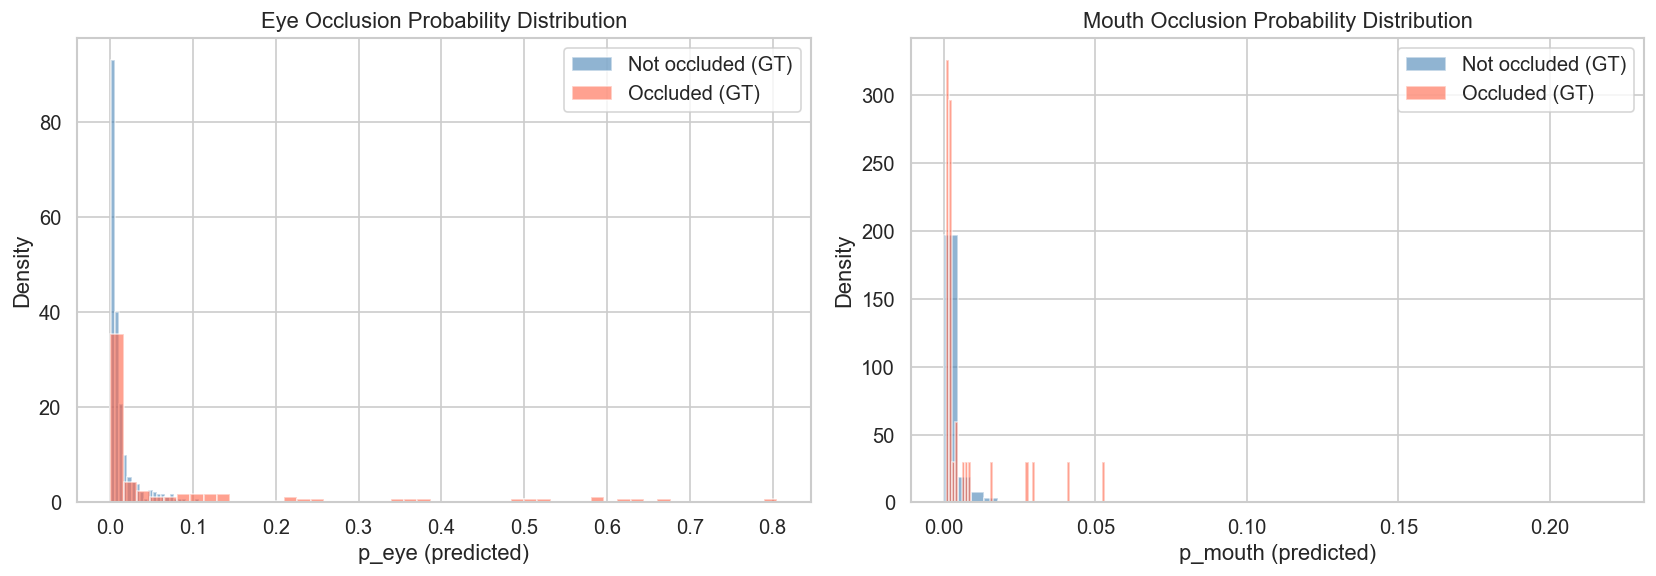

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# p_eye distribution
ax = axes[0]
ax.hist(df.loc[~df['eyes_occluded_prior'], 'p_eye'], bins=50, alpha=0.6, label='Not occluded (GT)', color='steelblue', density=True)
ax.hist(df.loc[df['eyes_occluded_prior'], 'p_eye'], bins=50, alpha=0.6, label='Occluded (GT)', color='tomato', density=True)
ax.set_xlabel('p_eye (predicted)')
ax.set_ylabel('Density')
ax.set_title('Eye Occlusion Probability Distribution')
ax.legend()

# p_mouth distribution
ax = axes[1]
ax.hist(df.loc[~df['mouth_occluded_prior'], 'p_mouth'], bins=50, alpha=0.6, label='Not occluded (GT)', color='steelblue', density=True)
ax.hist(df.loc[df['mouth_occluded_prior'], 'p_mouth'], bins=50, alpha=0.6, label='Occluded (GT)', color='tomato', density=True)
ax.set_xlabel('p_mouth (predicted)')
ax.set_ylabel('Density')
ax.set_title('Mouth Occlusion Probability Distribution')
ax.legend()

plt.tight_layout()
plt.savefig('output/audit_prob_distributions.png', bbox_inches='tight')
plt.show()

## 5. ROC-AUC Analysis

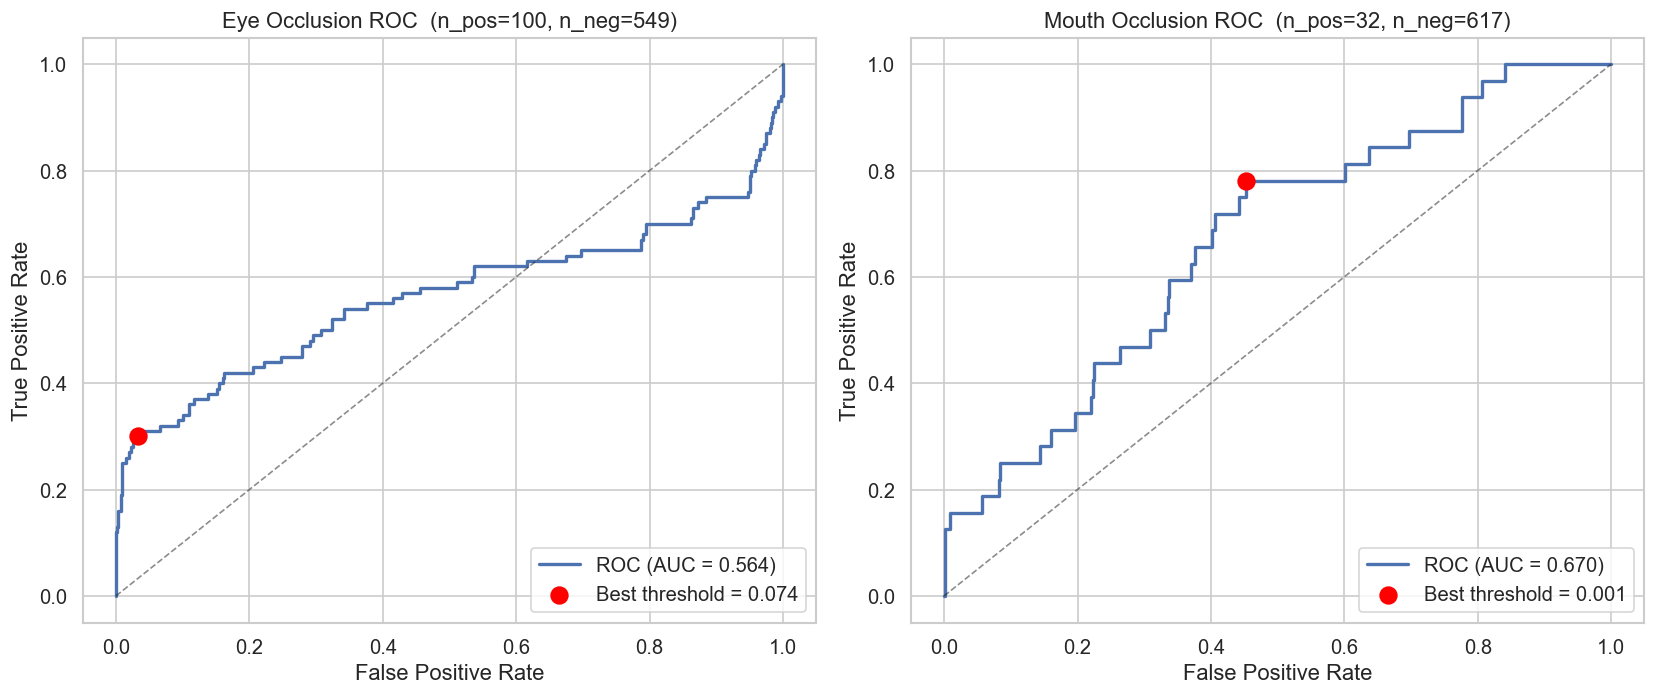


Eye   ROC-AUC: 0.5641894353369763
Mouth ROC-AUC: 0.6697224473257699


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

results_summary = {}

# --- Eye ROC ---
ax = axes[0]
y_true_eye = df['eyes_occluded_prior'].astype(int).values
y_score_eye = df['p_eye'].values

if y_true_eye.sum() > 0 and y_true_eye.sum() < len(y_true_eye):
    auc_eye = roc_auc_score(y_true_eye, y_score_eye)
    fpr, tpr, thresholds = roc_curve(y_true_eye, y_score_eye)
    ax.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {auc_eye:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    
    # Find best threshold (Youden's J)
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    best_thr_eye = thresholds[best_idx]
    ax.scatter(fpr[best_idx], tpr[best_idx], s=100, c='red', zorder=5,
               label=f'Best threshold = {best_thr_eye:.3f}')
    results_summary['eye_auc'] = auc_eye
    results_summary['eye_best_threshold'] = best_thr_eye
else:
    auc_eye = float('nan')
    ax.text(0.5, 0.5, 'Not enough\npositive/negative\nsamples', ha='center', va='center', fontsize=14)
    results_summary['eye_auc'] = auc_eye

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'Eye Occlusion ROC  (n_pos={y_true_eye.sum()}, n_neg={len(y_true_eye)-y_true_eye.sum()})')
ax.legend(loc='lower right')

# --- Mouth ROC ---
ax = axes[1]
y_true_mouth = df['mouth_occluded_prior'].astype(int).values
y_score_mouth = df['p_mouth'].values

if y_true_mouth.sum() > 0 and y_true_mouth.sum() < len(y_true_mouth):
    auc_mouth = roc_auc_score(y_true_mouth, y_score_mouth)
    fpr, tpr, thresholds = roc_curve(y_true_mouth, y_score_mouth)
    ax.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {auc_mouth:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    best_thr_mouth = thresholds[best_idx]
    ax.scatter(fpr[best_idx], tpr[best_idx], s=100, c='red', zorder=5,
               label=f'Best threshold = {best_thr_mouth:.3f}')
    results_summary['mouth_auc'] = auc_mouth
    results_summary['mouth_best_threshold'] = best_thr_mouth
else:
    auc_mouth = float('nan')
    ax.text(0.5, 0.5, 'Not enough\npositive/negative\nsamples', ha='center', va='center', fontsize=14)
    results_summary['mouth_auc'] = auc_mouth

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'Mouth Occlusion ROC  (n_pos={y_true_mouth.sum()}, n_neg={len(y_true_mouth)-y_true_mouth.sum()})')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('output/audit_roc_curves.png', bbox_inches='tight')
plt.show()

print(f"\nEye   ROC-AUC: {results_summary.get('eye_auc', 'N/A')}")
print(f"Mouth ROC-AUC: {results_summary.get('mouth_auc', 'N/A')}")

## 6. Per-Subject Analysis

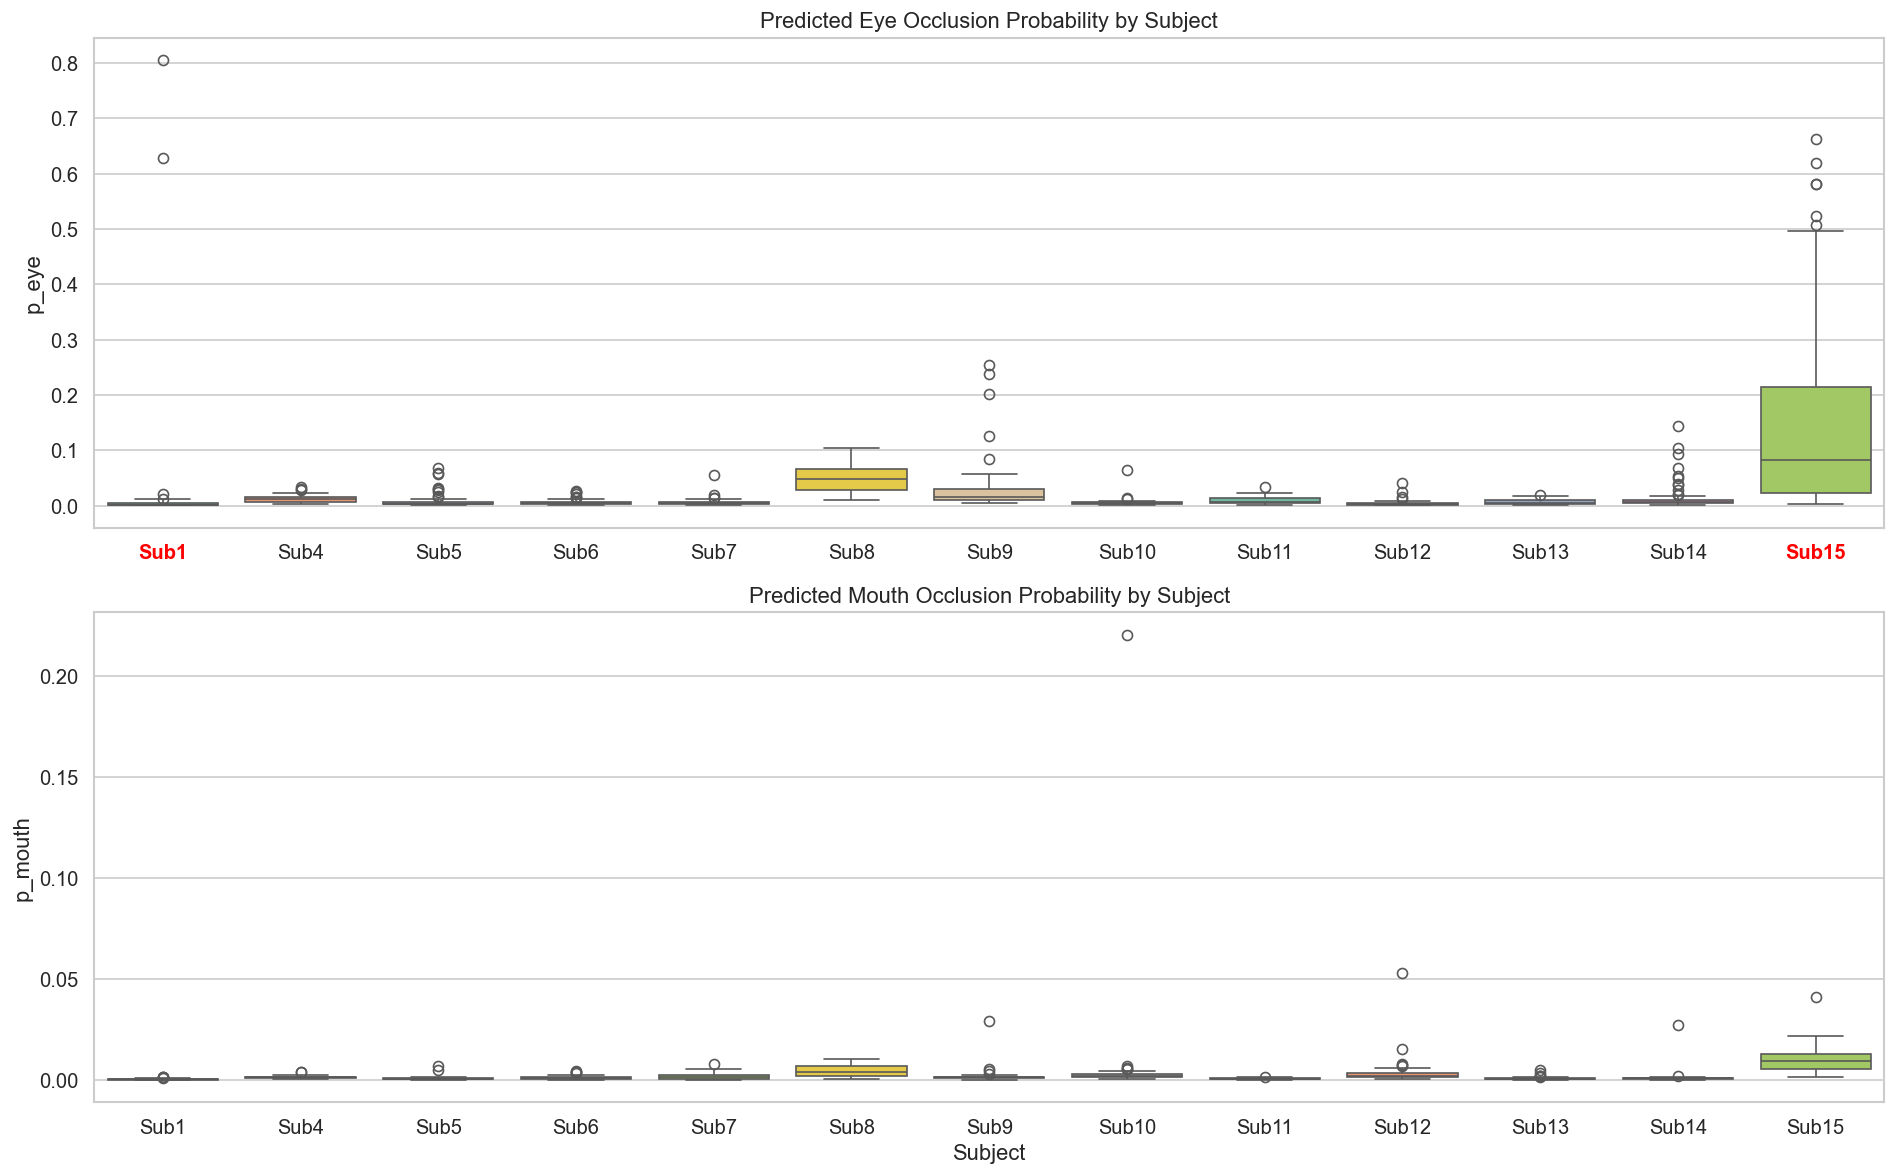

In [11]:
# Sort subjects numerically
subject_order = sorted(df['subject'].unique(), key=lambda s: int(s.replace('Sub', '')))

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# p_eye per subject
ax = axes[0]
sns.boxplot(data=df, x='subject', y='p_eye', order=subject_order, ax=ax, palette='Set2')
ax.set_title('Predicted Eye Occlusion Probability by Subject')
ax.set_ylabel('p_eye')
ax.set_xlabel('')
# Highlight glasses subjects
glasses_subs = df[df['glasses']]['subject'].unique()
for i, sub in enumerate(subject_order):
    if sub in glasses_subs:
        ax.get_xticklabels()[i].set_color('red')
        ax.get_xticklabels()[i].set_fontweight('bold')

# p_mouth per subject
ax = axes[1]
sns.boxplot(data=df, x='subject', y='p_mouth', order=subject_order, ax=ax, palette='Set2')
ax.set_title('Predicted Mouth Occlusion Probability by Subject')
ax.set_ylabel('p_mouth')
ax.set_xlabel('Subject')

plt.tight_layout()
plt.savefig('output/audit_per_subject_boxplots.png', bbox_inches='tight')
plt.show()

In [12]:
# Numeric summary per subject
per_sub = df.groupby('subject').agg(
    n=('p_eye', 'count'),
    p_eye_mean=('p_eye', 'mean'),
    p_eye_median=('p_eye', 'median'),
    p_eye_std=('p_eye', 'std'),
    p_mouth_mean=('p_mouth', 'mean'),
    p_mouth_median=('p_mouth', 'median'),
    p_mouth_std=('p_mouth', 'std'),
    eyes_occ_gt=('eyes_occluded_prior', 'mean'),
    mouth_occ_gt=('mouth_occluded_prior', 'mean'),
    glasses_pct=('glasses', 'mean'),
).sort_index(key=lambda x: x.str.extract(r'(\d+)')[0].astype(int))

print("Per-subject summary:")
print(per_sub.round(3).to_string())

Per-subject summary:
          n  p_eye_mean  p_eye_median  p_eye_std  p_mouth_mean  p_mouth_median  p_mouth_std  eyes_occ_gt  mouth_occ_gt  glasses_pct
subject                                                                                                                            
Sub1     50       0.032         0.002      0.142         0.000           0.000        0.000          1.0         0.080          1.0
Sub4     50       0.012         0.011      0.007         0.001           0.001        0.001          0.0         0.040          0.0
Sub5     50       0.009         0.003      0.015         0.001           0.001        0.001          0.0         0.040          0.0
Sub6     50       0.007         0.004      0.007         0.001           0.001        0.001          0.0         0.040          0.0
Sub7     50       0.006         0.005      0.008         0.002           0.001        0.002          0.0         0.060          0.0
Sub8     49       0.048         0.047      0.025       

## 7. Deep Dive: Subject 1 (Glasses)

SUBJECT 1 (GLASSES) vs ALL OTHER SUBJECTS

Sub1  p_eye:  mean=0.0321  median=0.0019  std=0.1425
Others p_eye: mean=0.0266  median=0.0067  std=0.0721

Sub1  p_mouth:  mean=0.0005  median=0.0004
Others p_mouth: mean=0.0030  median=0.0014

Mann-Whitney U (Sub1 p_eye > Others): U=6773, p=1.000000
  -> NOT significant at alpha=0.05


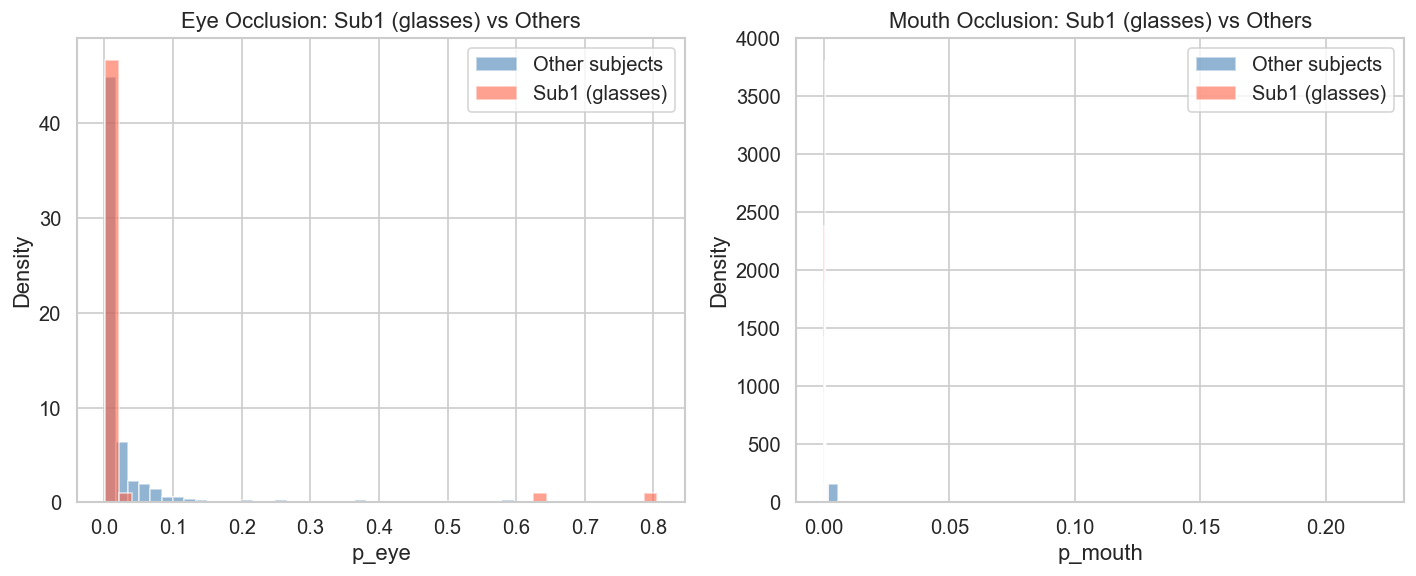

In [13]:
sub1 = df[df['subject'] == 'Sub1']
others = df[df['subject'] != 'Sub1']

print("=" * 60)
print("SUBJECT 1 (GLASSES) vs ALL OTHER SUBJECTS")
print("=" * 60)
print(f"\nSub1  p_eye:  mean={sub1['p_eye'].mean():.4f}  median={sub1['p_eye'].median():.4f}  std={sub1['p_eye'].std():.4f}")
print(f"Others p_eye: mean={others['p_eye'].mean():.4f}  median={others['p_eye'].median():.4f}  std={others['p_eye'].std():.4f}")
print(f"\nSub1  p_mouth:  mean={sub1['p_mouth'].mean():.4f}  median={sub1['p_mouth'].median():.4f}")
print(f"Others p_mouth: mean={others['p_mouth'].mean():.4f}  median={others['p_mouth'].median():.4f}")

# Statistical test
from scipy import stats
stat, pval = stats.mannwhitneyu(sub1['p_eye'].dropna(), others['p_eye'].dropna(), alternative='greater')
print(f"\nMann-Whitney U (Sub1 p_eye > Others): U={stat:.0f}, p={pval:.6f}")
print(f"  -> {'SIGNIFICANT' if pval < 0.05 else 'NOT significant'} at alpha=0.05")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.hist(others['p_eye'].dropna(), bins=40, alpha=0.6, label='Other subjects', density=True, color='steelblue')
ax.hist(sub1['p_eye'].dropna(), bins=40, alpha=0.6, label='Sub1 (glasses)', density=True, color='tomato')
ax.set_xlabel('p_eye')
ax.set_ylabel('Density')
ax.set_title('Eye Occlusion: Sub1 (glasses) vs Others')
ax.legend()

ax = axes[1]
ax.hist(others['p_mouth'].dropna(), bins=40, alpha=0.6, label='Other subjects', density=True, color='steelblue')
ax.hist(sub1['p_mouth'].dropna(), bins=40, alpha=0.6, label='Sub1 (glasses)', density=True, color='tomato')
ax.set_xlabel('p_mouth')
ax.set_ylabel('Density')
ax.set_title('Mouth Occlusion: Sub1 (glasses) vs Others')
ax.legend()

plt.tight_layout()
plt.savefig('output/audit_sub1_glasses_comparison.png', bbox_inches='tight')
plt.show()

## 8. Deep Dive: Mouth Occlusion (Yawn with Hand)

In [14]:
# Separate yawn frames by hand presence
yawn_hand = df[df['yawn_with_hand'] == True]
yawn_nohand = df[(df['class_label'] == 'Yawn') & (df['yawn_with_hand'] == False)]
neutral = df[df['class_label'] == 'Neutral']

print("=" * 60)
print("MOUTH OCCLUSION: YAWN-WITH-HAND vs YAWN-WITHOUT-HAND vs NEUTRAL")
print("=" * 60)

for label, subset in [('Yawn+Hand', yawn_hand), ('Yawn (no hand)', yawn_nohand), ('Neutral', neutral)]:
    if len(subset) > 0:
        print(f"\n{label} (n={len(subset)}):")
        print(f"  p_mouth: mean={subset['p_mouth'].mean():.4f}  median={subset['p_mouth'].median():.4f}  std={subset['p_mouth'].std():.4f}")
        print(f"  p_eye:   mean={subset['p_eye'].mean():.4f}  median={subset['p_eye'].median():.4f}")
        print(f"  mouth_occluded_prior (GT): {subset['mouth_occluded_prior'].mean()*100:.1f}%")
    else:
        print(f"\n{label}: No frames found.")

# Statistical test: yawn_with_hand vs yawn_without_hand
if len(yawn_hand) > 0 and len(yawn_nohand) > 0:
    stat, pval = stats.mannwhitneyu(yawn_hand['p_mouth'].dropna(), yawn_nohand['p_mouth'].dropna(), alternative='greater')
    print(f"\nMann-Whitney U (Yawn+Hand p_mouth > Yawn-nohand): U={stat:.0f}, p={pval:.6f}")
    print(f"  -> {'SIGNIFICANT' if pval < 0.05 else 'NOT significant'} at alpha=0.05")

MOUTH OCCLUSION: YAWN-WITH-HAND vs YAWN-WITHOUT-HAND vs NEUTRAL

Yawn+Hand (n=32):
  p_mouth: mean=0.0072  median=0.0018  std=0.0126
  p_eye:   mean=0.0313  median=0.0079
  mouth_occluded_prior (GT): 100.0%

Yawn (no hand) (n=42):
  p_mouth: mean=0.0013  median=0.0010  std=0.0014
  p_eye:   mean=0.0098  median=0.0056
  mouth_occluded_prior (GT): 0.0%

Neutral (n=491):
  p_mouth: mean=0.0024  median=0.0013  std=0.0030
  p_eye:   mean=0.0278  median=0.0055
  mouth_occluded_prior (GT): 0.0%

Mann-Whitney U (Yawn+Hand p_mouth > Yawn-nohand): U=1048, p=0.000021
  -> SIGNIFICANT at alpha=0.05


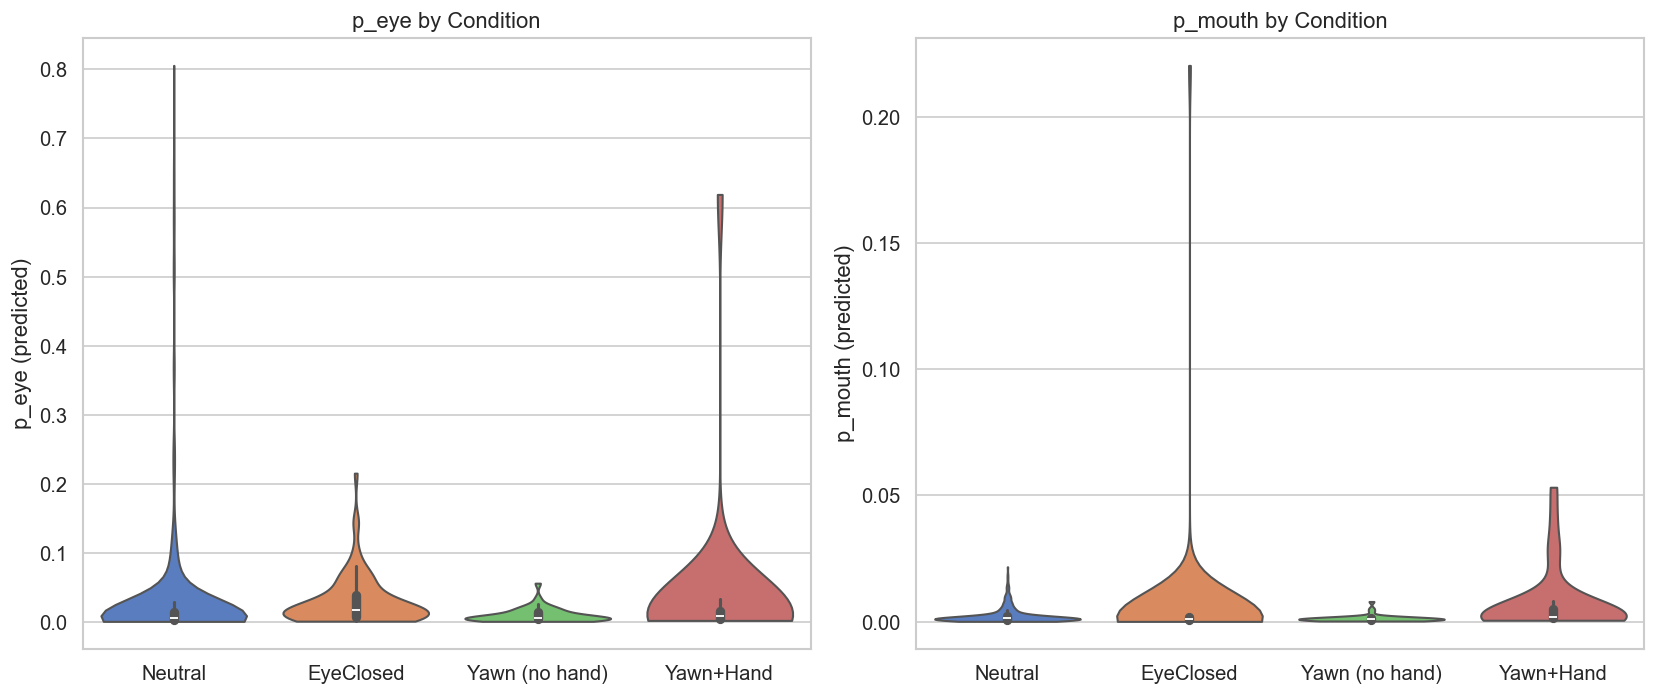

In [15]:
# Violin plot by category
plot_df = df.copy()
conditions = []
for _, row in plot_df.iterrows():
    if row['yawn_with_hand']:
        conditions.append('Yawn+Hand')
    elif row['class_label'] == 'Yawn':
        conditions.append('Yawn (no hand)')
    elif row['class_label'] == 'EyeClosed':
        conditions.append('EyeClosed')
    else:
        conditions.append('Neutral')
plot_df['condition'] = conditions

order = ['Neutral', 'EyeClosed', 'Yawn (no hand)', 'Yawn+Hand']
order = [o for o in order if o in plot_df['condition'].unique()]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
sns.violinplot(data=plot_df, x='condition', y='p_eye', order=order, ax=ax, palette='muted', cut=0)
ax.set_title('p_eye by Condition')
ax.set_xlabel('')
ax.set_ylabel('p_eye (predicted)')

ax = axes[1]
sns.violinplot(data=plot_df, x='condition', y='p_mouth', order=order, ax=ax, palette='muted', cut=0)
ax.set_title('p_mouth by Condition')
ax.set_xlabel('')
ax.set_ylabel('p_mouth (predicted)')

plt.tight_layout()
plt.savefig('output/audit_violin_by_condition.png', bbox_inches='tight')
plt.show()

## 9. Precision-Recall Analysis

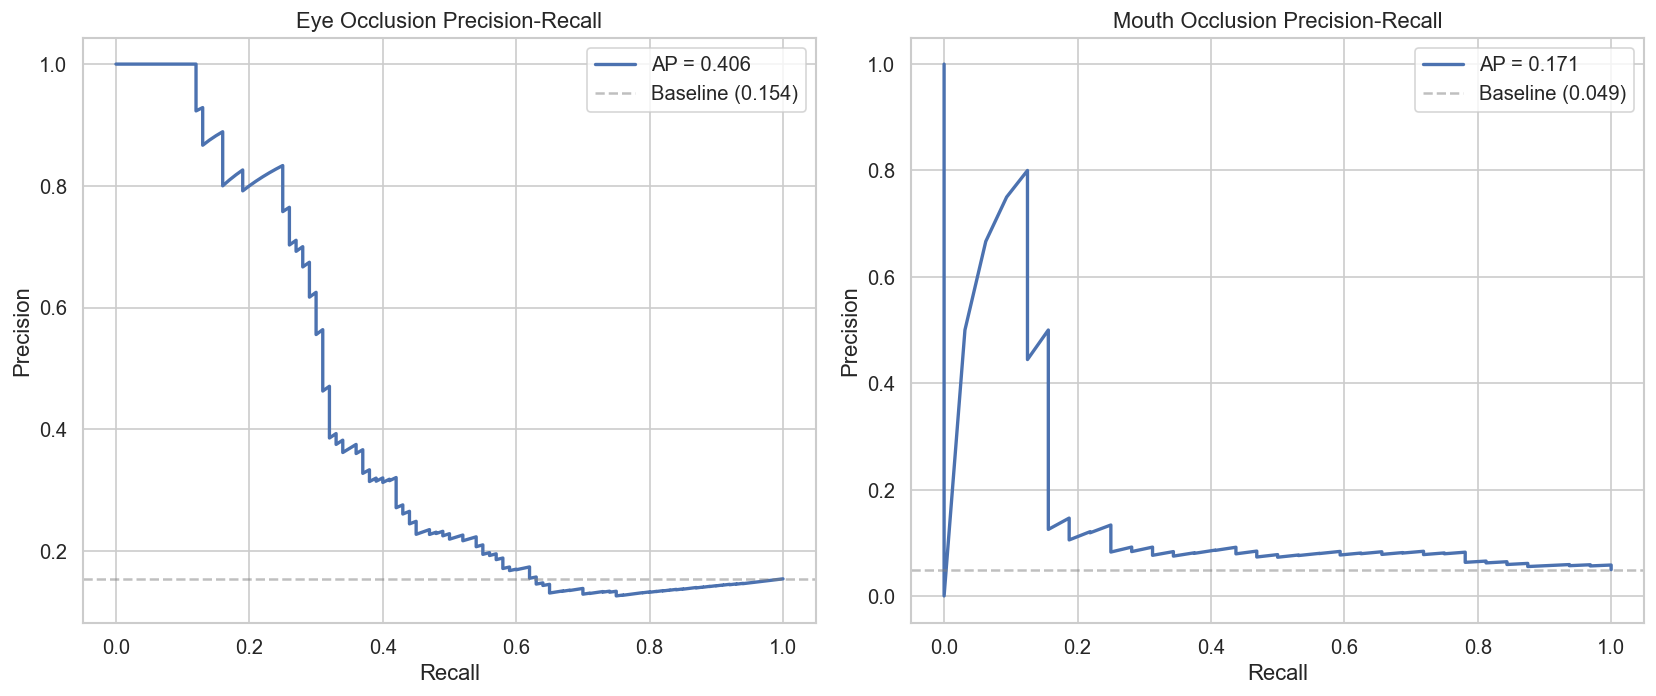

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Eye PR ---
ax = axes[0]
if y_true_eye.sum() > 0:
    prec, rec, thr_pr = precision_recall_curve(y_true_eye, y_score_eye)
    ap_eye = average_precision_score(y_true_eye, y_score_eye)
    ax.plot(rec, prec, lw=2, label=f'AP = {ap_eye:.3f}')
    ax.axhline(y=y_true_eye.mean(), color='gray', linestyle='--', alpha=0.5, label=f'Baseline ({y_true_eye.mean():.3f})')
    results_summary['eye_ap'] = ap_eye
else:
    ax.text(0.5, 0.5, 'No positive samples', ha='center', va='center', fontsize=14)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Eye Occlusion Precision-Recall')
ax.legend()

# --- Mouth PR ---
ax = axes[1]
if y_true_mouth.sum() > 0:
    prec, rec, thr_pr = precision_recall_curve(y_true_mouth, y_score_mouth)
    ap_mouth = average_precision_score(y_true_mouth, y_score_mouth)
    ax.plot(rec, prec, lw=2, label=f'AP = {ap_mouth:.3f}')
    ax.axhline(y=y_true_mouth.mean(), color='gray', linestyle='--', alpha=0.5, label=f'Baseline ({y_true_mouth.mean():.3f})')
    results_summary['mouth_ap'] = ap_mouth
else:
    ax.text(0.5, 0.5, 'No positive samples', ha='center', va='center', fontsize=14)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Mouth Occlusion Precision-Recall')
ax.legend()

plt.tight_layout()
plt.savefig('output/audit_precision_recall.png', bbox_inches='tight')
plt.show()

## 10. Threshold Sweep and Binary Classification Report

In [17]:
thresholds_to_try = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

print("=" * 70)
print("THRESHOLD SWEEP: EYE OCCLUSION")
print("=" * 70)

if y_true_eye.sum() > 0:
    for thr in thresholds_to_try:
        y_pred = (y_score_eye >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true_eye, y_pred, labels=[0, 1]).ravel()
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        acc = (tp + tn) / (tp + tn + fp + fn)
        print(f"  thr={thr:.1f}  TP={tp:4d}  FP={fp:4d}  FN={fn:4d}  TN={tn:4d}  "
              f"Prec={precision:.3f}  Rec={recall:.3f}  F1={f1:.3f}  Acc={acc:.3f}")
else:
    print("  No positive eye-occluded samples in dataset.")

print(f"\n{'=' * 70}")
print("THRESHOLD SWEEP: MOUTH OCCLUSION")
print("=" * 70)

if y_true_mouth.sum() > 0:
    for thr in thresholds_to_try:
        y_pred = (y_score_mouth >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true_mouth, y_pred, labels=[0, 1]).ravel()
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        acc = (tp + tn) / (tp + tn + fp + fn)
        print(f"  thr={thr:.1f}  TP={tp:4d}  FP={fp:4d}  FN={fn:4d}  TN={tn:4d}  "
              f"Prec={precision:.3f}  Rec={recall:.3f}  F1={f1:.3f}  Acc={acc:.3f}")
else:
    print("  No positive mouth-occluded samples in dataset.")

THRESHOLD SWEEP: EYE OCCLUSION
  thr=0.3  TP=  12  FP=   0  FN=  88  TN= 549  Prec=1.000  Rec=0.120  F1=0.214  Acc=0.864
  thr=0.4  TP=   9  FP=   0  FN=  91  TN= 549  Prec=1.000  Rec=0.090  F1=0.165  Acc=0.860
  thr=0.5  TP=   8  FP=   0  FN=  92  TN= 549  Prec=1.000  Rec=0.080  F1=0.148  Acc=0.858
  thr=0.6  TP=   4  FP=   0  FN=  96  TN= 549  Prec=1.000  Rec=0.040  F1=0.077  Acc=0.852
  thr=0.7  TP=   1  FP=   0  FN=  99  TN= 549  Prec=1.000  Rec=0.010  F1=0.020  Acc=0.847
  thr=0.8  TP=   1  FP=   0  FN=  99  TN= 549  Prec=1.000  Rec=0.010  F1=0.020  Acc=0.847
  thr=0.9  TP=   0  FP=   0  FN= 100  TN= 549  Prec=0.000  Rec=0.000  F1=0.000  Acc=0.846

THRESHOLD SWEEP: MOUTH OCCLUSION
  thr=0.3  TP=   0  FP=   0  FN=  32  TN= 617  Prec=0.000  Rec=0.000  F1=0.000  Acc=0.951
  thr=0.4  TP=   0  FP=   0  FN=  32  TN= 617  Prec=0.000  Rec=0.000  F1=0.000  Acc=0.951
  thr=0.5  TP=   0  FP=   0  FN=  32  TN= 617  Prec=0.000  Rec=0.000  F1=0.000  Acc=0.951
  thr=0.6  TP=   0  FP=   0  FN=  3

## 11. Correlation: Predicted Probabilities vs Ground Truth

In [18]:
from scipy.stats import pointbiserialr, spearmanr

print("=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)

# Point-biserial correlation (continuous vs binary)
if df['eyes_occluded_prior'].nunique() > 1:
    corr_eye, pval_eye = pointbiserialr(df['eyes_occluded_prior'].astype(int), df['p_eye'])
    print(f"\np_eye vs eyes_occluded_prior:  r_pb = {corr_eye:.4f}, p = {pval_eye:.2e}")
else:
    print("\np_eye vs eyes_occluded_prior: only one class present, cannot compute correlation.")

if df['mouth_occluded_prior'].nunique() > 1:
    corr_mouth, pval_mouth = pointbiserialr(df['mouth_occluded_prior'].astype(int), df['p_mouth'])
    print(f"p_mouth vs mouth_occluded_prior: r_pb = {corr_mouth:.4f}, p = {pval_mouth:.2e}")
else:
    print("p_mouth vs mouth_occluded_prior: only one class present, cannot compute correlation.")

# Spearman correlation between the two predicted probs
corr_both, pval_both = spearmanr(df['p_eye'], df['p_mouth'])
print(f"\np_eye vs p_mouth (Spearman): rho = {corr_both:.4f}, p = {pval_both:.2e}")
print(f"  -> {'High' if abs(corr_both) > 0.5 else 'Low'} correlation between the two output heads.")

CORRELATION ANALYSIS

p_eye vs eyes_occluded_prior:  r_pb = 0.3695, p = 1.98e-22
p_mouth vs mouth_occluded_prior: r_pb = 0.1044, p = 7.80e-03

p_eye vs p_mouth (Spearman): rho = 0.5488, p = 2.56e-52
  -> High correlation between the two output heads.


## 12. Analysis by Class Label and Variant

In [19]:
print("=" * 60)
print("PREDICTIONS BY CLASS LABEL")
print("=" * 60)

for cls in ['Neutral', 'EyeClosed', 'Yawn']:
    subset = df[df['class_label'] == cls]
    if len(subset) == 0:
        continue
    print(f"\n{cls} (n={len(subset)}):")
    print(f"  p_eye:   mean={subset['p_eye'].mean():.4f}  std={subset['p_eye'].std():.4f}")
    print(f"  p_mouth: mean={subset['p_mouth'].mean():.4f}  std={subset['p_mouth'].std():.4f}")

print(f"\n{'=' * 60}")
print("PREDICTIONS BY VARIANT (top 10)")
print("=" * 60)

var_stats = df.groupby('variant').agg(
    n=('p_eye', 'count'),
    p_eye_mean=('p_eye', 'mean'),
    p_mouth_mean=('p_mouth', 'mean'),
    eyes_occ_gt=('eyes_occluded_prior', 'mean'),
    mouth_occ_gt=('mouth_occluded_prior', 'mean'),
).sort_values('n', ascending=False)
print(var_stats.head(10).round(3).to_string())

PREDICTIONS BY CLASS LABEL

Neutral (n=491):
  p_eye:   mean=0.0278  std=0.0858
  p_mouth: mean=0.0024  std=0.0030

EyeClosed (n=84):
  p_eye:   mean=0.0298  std=0.0363
  p_mouth: mean=0.0045  std=0.0240

Yawn (n=74):
  p_eye:   mean=0.0191  std=0.0718
  p_mouth: mean=0.0038  std=0.0088

PREDICTIONS BY VARIANT (top 10)
                      n  p_eye_mean  p_mouth_mean  eyes_occ_gt  mouth_occ_gt
variant                                                                     
Neutral             419       0.013         0.002        0.000           0.0
Neutral_Occluded     72       0.115         0.006        1.000           0.0
EyeClosed            69       0.028         0.005        0.000           0.0
Yawn_Occluded        40       0.026         0.006        0.325           0.8
Yawn                 34       0.011         0.001        0.000           0.0
EyeClosed_Occluded   15       0.040         0.004        1.000           0.0


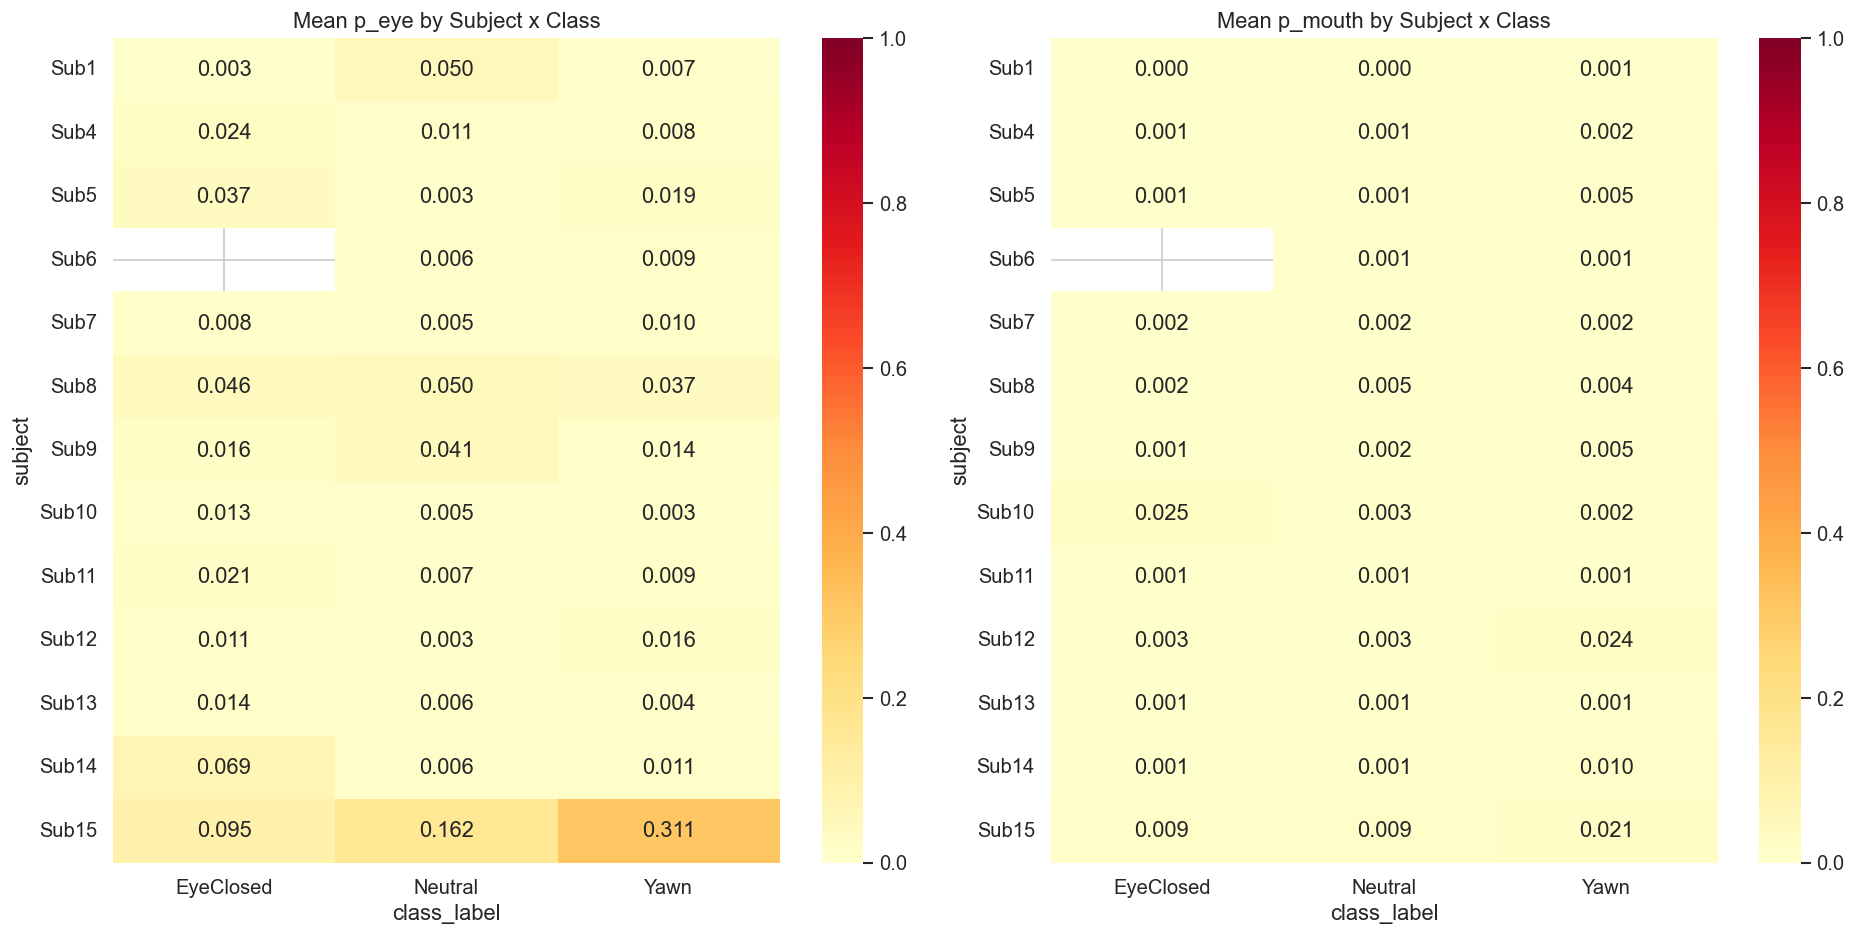

In [20]:
# Heatmap: mean p_eye and p_mouth by (subject, class_label)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

pivot_eye = df.pivot_table(values='p_eye', index='subject', columns='class_label', aggfunc='mean')
pivot_eye = pivot_eye.reindex(subject_order)
ax = axes[0]
sns.heatmap(pivot_eye, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax, vmin=0, vmax=1)
ax.set_title('Mean p_eye by Subject x Class')

pivot_mouth = df.pivot_table(values='p_mouth', index='subject', columns='class_label', aggfunc='mean')
pivot_mouth = pivot_mouth.reindex(subject_order)
ax = axes[1]
sns.heatmap(pivot_mouth, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax, vmin=0, vmax=1)
ax.set_title('Mean p_mouth by Subject x Class')

plt.tight_layout()
plt.savefig('output/audit_heatmap_subject_class.png', bbox_inches='tight')
plt.show()

## 13. Detection Score Analysis

Spearman(det_score, p_eye)   = -0.1570
Spearman(det_score, p_mouth) = -0.1104


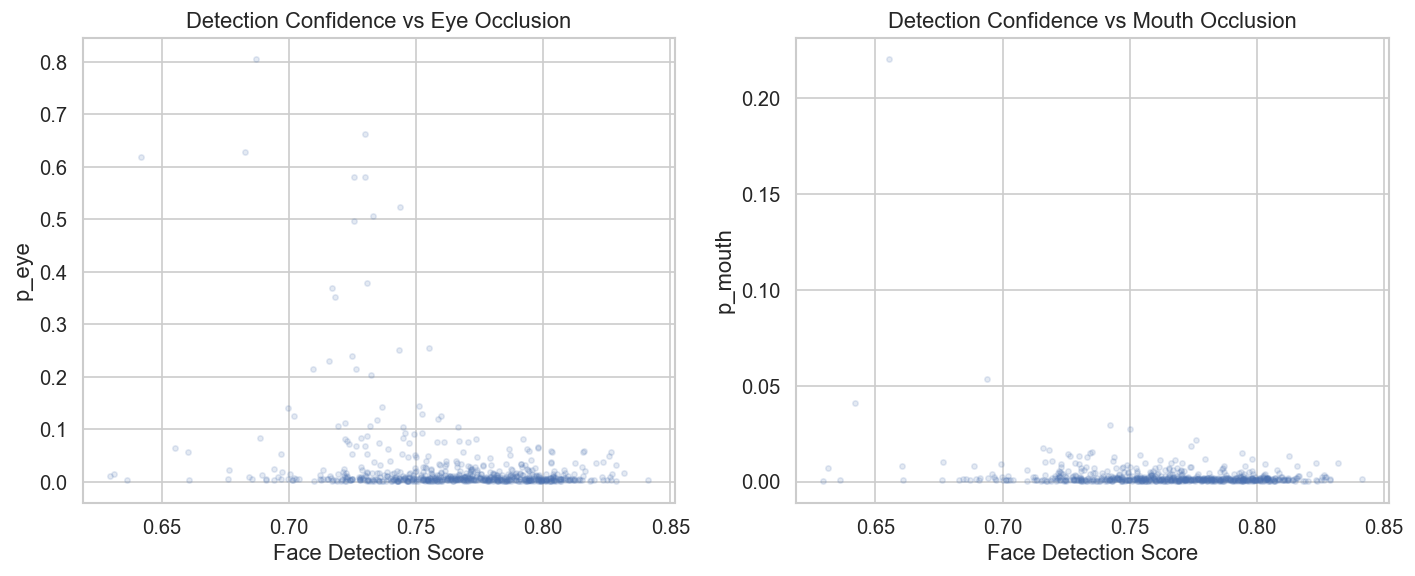

In [21]:
# Does face detection confidence correlate with occlusion predictions?
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(df['det_score'], df['p_eye'], alpha=0.15, s=10)
ax.set_xlabel('Face Detection Score')
ax.set_ylabel('p_eye')
ax.set_title('Detection Confidence vs Eye Occlusion')

ax = axes[1]
ax.scatter(df['det_score'], df['p_mouth'], alpha=0.15, s=10)
ax.set_xlabel('Face Detection Score')
ax.set_ylabel('p_mouth')
ax.set_title('Detection Confidence vs Mouth Occlusion')

# Correlation
corr_det_eye, _ = spearmanr(df['det_score'].dropna(), df['p_eye'].dropna())
corr_det_mouth, _ = spearmanr(df['det_score'].dropna(), df['p_mouth'].dropna())
print(f"Spearman(det_score, p_eye)   = {corr_det_eye:.4f}")
print(f"Spearman(det_score, p_mouth) = {corr_det_mouth:.4f}")

plt.tight_layout()
plt.savefig('output/audit_det_score_vs_occlusion.png', bbox_inches='tight')
plt.show()

## 14. Summary and Conclusions

In [22]:
print("=" * 70)
print("OCCLUSION ESTIMATOR AUDIT: SUMMARY")
print("=" * 70)

print(f"\nDataset: {len(df)} valid frames from {df['subject'].nunique()} subjects")
print(f"Face detection success rate: {results_df['face_detected'].mean()*100:.1f}%")

print(f"\n--- Eye Occlusion ---")
print(f"  GT positive rate: {df['eyes_occluded_prior'].mean()*100:.1f}%")
print(f"  Mean p_eye (occluded GT):     {df.loc[df['eyes_occluded_prior'], 'p_eye'].mean():.4f}" if df['eyes_occluded_prior'].any() else "  No occluded eye frames.")
print(f"  Mean p_eye (not occluded GT): {df.loc[~df['eyes_occluded_prior'], 'p_eye'].mean():.4f}")
if 'eye_auc' in results_summary:
    print(f"  ROC-AUC: {results_summary['eye_auc']:.3f}")
if 'eye_ap' in results_summary:
    print(f"  Average Precision: {results_summary['eye_ap']:.3f}")

print(f"\n--- Mouth Occlusion ---")
print(f"  GT positive rate: {df['mouth_occluded_prior'].mean()*100:.1f}%")
print(f"  Mean p_mouth (occluded GT):     {df.loc[df['mouth_occluded_prior'], 'p_mouth'].mean():.4f}" if df['mouth_occluded_prior'].any() else "  No occluded mouth frames.")
print(f"  Mean p_mouth (not occluded GT): {df.loc[~df['mouth_occluded_prior'], 'p_mouth'].mean():.4f}")
if 'mouth_auc' in results_summary:
    print(f"  ROC-AUC: {results_summary['mouth_auc']:.3f}")
if 'mouth_ap' in results_summary:
    print(f"  Average Precision: {results_summary['mouth_ap']:.3f}")

print(f"\n--- Key Findings ---")
if 'Sub1' in df['subject'].values:
    s1_eye = df.loc[df['subject'] == 'Sub1', 'p_eye'].mean()
    oth_eye = df.loc[df['subject'] != 'Sub1', 'p_eye'].mean()
    print(f"  Sub1 (glasses) p_eye = {s1_eye:.4f} vs others = {oth_eye:.4f}  (ratio: {s1_eye/oth_eye:.2f}x)")

if len(yawn_hand) > 0 and len(yawn_nohand) > 0:
    ywh = yawn_hand['p_mouth'].mean()
    ywnh = yawn_nohand['p_mouth'].mean()
    print(f"  Yawn+Hand p_mouth = {ywh:.4f} vs Yawn-nohand = {ywnh:.4f}  (ratio: {ywh/ywnh:.2f}x)" if ywnh > 0 else "  Yawn-nohand p_mouth = 0")

print(f"\n--- Interpretation for Journal ---")
print("  - If AUC > 0.7: The estimator transfers reasonably well from ROF to DMD.")
print("  - If AUC ~ 0.5: The estimator is NOT distinguishing occluded from non-occluded DMD frames.")
print("    -> This means the gating pipeline has no meaningful signal to work with.")
print("    -> The model may still work via learned feature patterns, but gates aren't contributing.")
print("  - If Sub1 p_eye >> others: Glasses are being detected as a form of eye occlusion.")
print("  - If Yawn+Hand p_mouth >> Yawn-nohand: Hand-over-mouth IS being detected.")

OCCLUSION ESTIMATOR AUDIT: SUMMARY

Dataset: 649 valid frames from 13 subjects
Face detection success rate: 100.0%

--- Eye Occlusion ---
  GT positive rate: 15.4%
  Mean p_eye (occluded GT):     0.0959
  Mean p_eye (not occluded GT): 0.0145
  ROC-AUC: 0.564
  Average Precision: 0.406

--- Mouth Occlusion ---
  GT positive rate: 4.9%
  Mean p_mouth (occluded GT):     0.0072
  Mean p_mouth (not occluded GT): 0.0026
  ROC-AUC: 0.670
  Average Precision: 0.171

--- Key Findings ---
  Sub1 (glasses) p_eye = 0.0321 vs others = 0.0266  (ratio: 1.21x)
  Yawn+Hand p_mouth = 0.0072 vs Yawn-nohand = 0.0013  (ratio: 5.49x)

--- Interpretation for Journal ---
  - If AUC > 0.7: The estimator transfers reasonably well from ROF to DMD.
  - If AUC ~ 0.5: The estimator is NOT distinguishing occluded from non-occluded DMD frames.
    -> This means the gating pipeline has no meaningful signal to work with.
    -> The model may still work via learned feature patterns, but gates aren't contributing.
  - If

In [23]:
# Save full summary for reference
import json

summary_out = {
    'n_subjects': int(df['subject'].nunique()),
    'n_frames_total': len(results_df),
    'n_frames_valid': len(df),
    'face_detection_rate': float(results_df['face_detected'].mean()),
    'eye_gt_positive_rate': float(df['eyes_occluded_prior'].mean()),
    'mouth_gt_positive_rate': float(df['mouth_occluded_prior'].mean()),
}
summary_out.update({k: float(v) for k, v in results_summary.items() if not np.isnan(v)})

with open('occlusion_audit_summary.json', 'w') as f:
    json.dump(summary_out, f, indent=2)
print('Saved: occlusion_audit_summary.json')
print(json.dumps(summary_out, indent=2))

Saved: occlusion_audit_summary.json
{
  "n_subjects": 13,
  "n_frames_total": 649,
  "n_frames_valid": 649,
  "face_detection_rate": 1.0,
  "eye_gt_positive_rate": 0.15408320493066255,
  "mouth_gt_positive_rate": 0.04930662557781202,
  "eye_auc": 0.5641894353369763,
  "eye_best_threshold": 0.07409505546092987,
  "mouth_auc": 0.6697224473257699,
  "mouth_best_threshold": 0.0013575274497270584,
  "eye_ap": 0.4056404770089327,
  "mouth_ap": 0.17065365364348725
}
